In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print('All libraries imported successfully!')

All libraries imported successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/mbti_1.csv', engine='python', on_bad_lines='skip')
df.head()

,type,posts
0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...
1,ENTP,'I'm finding the lack of me in these posts ver...
2,INTP,'Good one _____ https://www.youtube.com/wat...
3,INTJ,"'Dear INTP, I enjoyed our conversation the o..."
4,ENTJ,'You're fired.|||That's another silly misconce...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4783 entries, 0 to 4782
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   type    4783 non-null   object
 1   posts   4783 non-null   object
dtypes: object(2)
memory usage: 74.9+ KB


In [ ]:
df.describe()

,type,posts
count,4783,4783
unique,16,4783
top,INFP,'Fi> Fe = Si = Ni > Se = Ne > Ti > Te 90 80 ...
freq,1018,1


In [ ]:
df.shape

(4783, 2)

In [ ]:
df.columns

Index(['type', 'posts'], dtype='object')

In [ ]:
df['type'].unique()

array(['INFJ', 'ENTP', 'INTP', 'INTJ', 'ENTJ', 'ENFJ', 'INFP', 'ENFP',
       'ISFP', 'ISTP', 'ISFJ', 'ISTJ', 'ESTP', 'ESFP', 'ESTJ', 'ESFJ'],
      dtype=object)

In [ ]:
df['type'].value_counts()

,count
type,
INFP,1018
INFJ,827
INTP,721
INTJ,584
ENTP,390
ENFP,361
ISTP,189
ISFP,142
ENTJ,117


In [ ]:
df.isnull().sum()


,0
type,0
posts,0


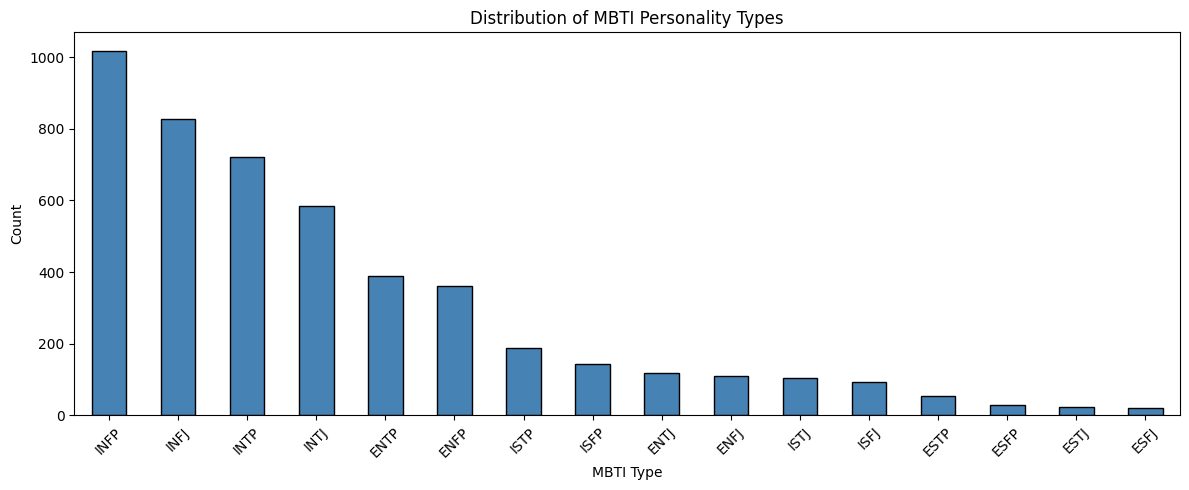

In [ ]:
plt.figure(figsize=(12,5))
df['type'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribution of MBTI Personality Types')
plt.xlabel('MBTI Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
def clean_text(text):
    text = re.sub(r'http\S+|www\S+', '', text)
    mbti_types = ['INFJ','INFP','INTJ','INTP','ISFJ','ISFP','ISTJ','ISTP',
                  'ENFJ','ENFP','ENTJ','ENTP','ESFJ','ESFP','ESTJ','ESTP']
    for t in mbti_types:
        text = re.sub(t, '', text, flags=re.IGNORECASE)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower().strip()
    return text

df['cleaned_posts'] = df['posts'].apply(clean_text)
df[['type','cleaned_posts']].head()

,type,cleaned_posts
0,INFJ,and moments sportscenter not top ten plays...
1,ENTP,im finding the lack of me in these posts very ...
2,INTP,good one course to which i say i know tha...
3,INTJ,dear i enjoyed our conversation the other d...
4,ENTJ,youre firedthats another silly misconception t...


In [ ]:
tfidf = TfidfVectorizer(max_features=3000, stop_words='english')
X_tfidf = tfidf.fit_transform(df['cleaned_posts']).toarray()

le = LabelEncoder()
y_encoded = le.fit_transform(df['type'])

print('Feature matrix shape:', X_tfidf.shape)
print('Classes:', le.classes_)

Feature matrix shape: (4783, 3000)
Classes: ['ENFJ' 'ENFP' 'ENTJ' 'ENTP' 'ESFJ' 'ESFP' 'ESTJ' 'ESTP' 'INFJ' 'INFP'
 'INTJ' 'INTP' 'ISFJ' 'ISFP' 'ISTJ' 'ISTP']


SVC




In [ ]:
X = X_tfidf
print(X.shape)

(4783, 3000)


In [ ]:
y = y_encoded
print(y.shape)

(4783,)


80-30 Split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(3826, 3000) (957, 3000)


In [ ]:
print(X_train)

[[0.         0.07602145 0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.07736946 0.         0.033649   ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]


In [ ]:
from sklearn.svm import SVC
svc2 = SVC()
svc2.fit(X_train, y_train)
y_pred = svc2.predict(X_test)
print('Model accuracy score with default hyperparameters: {0:0.4f}'.format(accuracy_score(y_test, y_pred)))

Model accuracy score with default hyperparameters: 0.3521


In [27]:
linear_svc2 = SVC(kernel='linear', C=1.0)
linear_svc2.fit(X_train, y_train)
y_pred = linear_svc2.predict(X_test)
print('Model accuracy score with linear kernel and C=1.0: {0:.4f}'.format(accuracy_score(y_test, y_pred)))

Model accuracy score with linear kernel and C=1.0: 0.3710


In [28]:
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[  0   1   0   1   0   0   0   0   2   8   1   1   0   0   0   0]
 [  0   8   0   3   0   0   0   0  18  35   2   6   0   0   0   0]
 [  0   1   0   1   0   0   0   0   0   4   7   3   0   0   0   0]
 [  0   3   0  13   0   0   0   0  13  18  13  25   0   0   0   0]
 [  0   0   0   0   0   0   0   0   1   1   1   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   1   0   2   0   0   0   0]
 [  0   0   0   0   0   0   0   0   2   0   1   0   0   0   0   0]
 [  0   1   0   1   0   0   0   0   1   1   0   2   0   0   0   0]
 [  0   2   0   0   0   0   0   0  69  69  20  13   0   0   0   0]
 [  0   3   0   0   0   0   0   0  30 162  13  19   0   0   0   0]
 [  0   1   0   1   0   0   0   0  24  11  38  43   0   0   0   0]
 [  0   1   0   2   0   0   0   0  26  23  19  64   0   0   0   0]
 [  0   0   0   0   0   0   0   0   8   6   3   3   0   0   0   0]
 [  0   1   0   0   0   0   0   0  11  16   5   0   0   0   0   0]
 [  0   0   0   1   0   0   0   0   4   3   

In [29]:
print('Accuracy Score:')
print(accuracy_score(y_test, y_pred))

Accuracy Score:
0.3709508881922675


In [30]:
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

Classification Report:
              precision    recall  f1-score   support

        ENFJ       0.00      0.00      0.00        14
        ENFP       0.36      0.11      0.17        72
        ENTJ       0.00      0.00      0.00        16
        ENTP       0.54      0.15      0.24        85
        ESFJ       0.00      0.00      0.00         3
        ESFP       0.00      0.00      0.00         3
        ESTJ       0.00      0.00      0.00         3
        ESTP       0.00      0.00      0.00         6
        INFJ       0.32      0.40      0.35       173
        INFP       0.44      0.71      0.54       227
        INTJ       0.29      0.32      0.31       118
        INTP       0.33      0.47      0.39       135
        ISFJ       0.00      0.00      0.00        20
        ISFP       0.00      0.00      0.00        33
        ISTJ       0.00      0.00      0.00        15
        ISTP       1.00      0.03      0.06        34

    accuracy                           0.37       957
   

*Result* of 80:30 Split


In [33]:
# ── Table 2 : 80:20 Split — SVM (SVC) ──
Xtr,Xte,ytr,yte = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=42)
m = SVC(kernel='linear', C=1.0)
m.fit(Xtr, ytr)
yp = m.predict(Xte)
rep = classification_report(yte, yp, output_dict=True, zero_division=0)
svm_t80 = pd.DataFrame([{
    'Split'         : '80:20',
    'Train Samples' : Xtr.shape[0],
    'Test Samples'  : Xte.shape[0],
    'Accuracy(%)'   : round(accuracy_score(yte,yp)*100,2),
    'Precision(W)'  : round(rep['weighted avg']['precision']*100,2),
    'Recall(W)'     : round(rep['weighted avg']['recall']*100,2),
    'F1-Score(W)'   : round(rep['weighted avg']['f1-score']*100,2)
}])
svm_t80.index += 1
print('===== SVM (SVC) — Results Table : 80:20 Split =====')
svm_t80

===== SVM (SVC) — Results Table : 80:20 Split =====


,Split,Train Samples,Test Samples,Accuracy(%),Precision(W),Recall(W),F1-Score(W)
1,80:20,3826,957,37.1,35.51,37.1,32.15
